# Exercise 1 detailed solution: what an extended $S+B$ NLL fit is doing

This notebook is a slower, more fundamental version of the solution to Exercise 1 of the INSS statistics exercises.

The goal is not just to get the numerical answer. The goal is to understand what is being fit, why the likelihood has the form it has, how the signal and background templates become predicted event counts, how uncertainties enter the fit, and why the negative log-likelihood looks approximately parabolic near the best fit. If we are going to make a detailed presentation about a question, we can follow this outline.

We acknowledge the use of ChatGPT 5 for coding help.

## Lecture references used here

- `INSS_LectureStats_I.pdf`, slide 32: likelihood and maximum-likelihood estimation.
- `INSS_LectureStats_I.pdf`, slides 36--38: the relation between likelihood, negative log-likelihood, parabolic approximations, and $	riangle	ext{NLL}$ intervals.
- `INSS_LectureStats_I.pdf`, slide 42: profile likelihood scans.
- `INSS_LectureStats_II.pdf`, slide 8: the extended $S+B$ likelihood, where the total number of expected events is part of the model.
- `INSS_LectureStats_II.pdf`, slide 9: vertical morphing for shape systematics.
- `INSS_LectureStats_II.pdf`, slides 3--4: profiling nuisance parameters.

I cite these lectures directly because the exercise is based on their likelihood/profile-likelihood framework.

## 1. What is the data?

The data in this exercise are already binned into a histogram of a multivariate discriminant score.

For each bin $i$, the observed data are

$$
 d_i = \text{number of observed events in bin } i.
$$

So the object we fit is not one number. It is the full list of bin counts:

$$
(d_1,d_2,\ldots,d_N).
$$

Because these are event counts, the natural statistical model is a Poisson model. If the model predicts an expected number of events $\mu_i$ in bin $i$, then

$$
P(d_i\mid \mu_i)=\frac{\mu_i^{d_i}e^{-\mu_i}}{d_i!}.
$$

The key idea is:

> The fit changes the model parameters until the predicted bin counts $\mu_i$ make the observed counts $d_i$ as likely as possible.

## 2. Signal and background templates:

The input file contains four shape histograms:

- `s_pdf`: the signal shape.
- `b_pdf`: the nominal background shape.
- `b1_pdf`: the $+1\sigma$ shifted background shape.
- `b2_pdf`: the $-1\sigma$ shifted background shape.

These are called PDFs in the exercise because they describe **fractions of events across bins**. They are normalized so that

$$
\sum_i s_i = 1, \qquad \sum_i b_i = 1.
$$

That means $s_i$ is not the number of signal events in bin $i$. It is the fraction of signal events expected in bin $i$.

If the total number of signal events is $S$, then the expected signal count in bin $i$ is

$$
S s_i.
$$

If the total number of background events is $B$, then the expected background count in bin $i$ is

$$
B b_i.
$$

Therefore the total expected count in bin $i$ is

$$
\mu_i(S,B)=S s_i + B b_i.
$$

This is the main answer to the question “what are we fitting?” We are fitting the parameters $S$ and $B$, which turn normalized signal/background shapes into absolute predicted event counts.

## 3. Description of an extended likelihood:

There are two related but different questions one could ask:

1. Given that I observed exactly $N$ events, what fraction of them look signal-like versus background-like?
2. What total number of signal and background events best explains both the **shape** and the **total event count**?

Exercise 1 asks for the second version. That is why the lecture calls this an **extended** $S+B$ likelihood (`INSS_LectureStats_II.pdf`, slide 8).

In an extended binned fit, the total predicted number of events

$$
\sum_i \mu_i = S+B
$$

is part of the model. The likelihood cares if $S+B$ predicts too many or too few total events.

## 4. Typical Chi Square vs Poisson Uncertainties

For a binned event-counting experiment, each bin count has Poisson uncertainty. Roughly, for a count $d_i$, the standard deviation is

$$
\sigma_i \approx \sqrt{d_i}.
$$

But in a Poisson likelihood fit, we do **not** manually assign weights like $1/\sigma_i^2$ in the objective function. The Poisson probability already knows that bins with larger expected counts have larger absolute fluctuations.

The full binned likelihood is the product over bins:

$$
L(S,B)=\prod_i P(d_i\mid \mu_i(S,B)).
$$

Equivalently,

$$
L(S,B)=\prod_i \frac{\mu_i(S,B)^{d_i}e^{-\mu_i(S,B)}}{d_i!}.
$$

The negative log-likelihood, dropping constants that do not depend on $S$ or $B$, is

$$
\text{NLL}(S,B)=\sum_i \left[\mu_i(S,B)-d_i\ln\mu_i(S,B)\right].
$$

This is what we minimize.

For large counts, this Poisson NLL becomes closely related to a $\chi^2$ fit. Expanding around $\mu_i\approx d_i$ gives approximately

$$
\text{NLL} \approx \text{constant}+\frac{1}{2}\sum_i \frac{(d_i-\mu_i)^2}{\mu_i}.
$$

So the usual $\chi^2$ weights appear as an approximation to the likelihood, not as something we need to insert manually.

## 5. What if we exactly knew the PDFs (background has no uncertainty):

If the signal and background shapes were known perfectly, then the model would only need the yields $S$ and $B$:

$$
\mu_i(S,B)=S s_i+B b_i.
$$

Then the fit asks:

> For each possible pair $(S,B)$, how likely is it that Poisson fluctuations around $\mu_i(S,B)$ would have produced the observed counts $d_i$?

The best fit is the pair $(\hat S,\hat B)$ that makes this likelihood largest, or equivalently makes the NLL smallest.

That is the cleanest version of the problem.

## 6. If the background shape has uncertainty:

The exercise also gives two shifted background shapes, `b1_pdf` and `b2_pdf`, representing $\pm 1\sigma$ variations.

We introduce a nuisance parameter $\alpha$:

- $\alpha=0$: use the nominal background shape.
- $\alpha=+1$: use the $+1\sigma$ shifted background shape.
- $\alpha=-1$: use the $-1\sigma$ shifted background shape.

This follows the vertical morphing idea from `INSS_LectureStats_II.pdf`, slide 9.

The model becomes

$$
\mu_i(S,B,\alpha)=S s_i+B b_i(\alpha).
$$

Because $\alpha$ is supposed to be a one-standard-deviation systematic variable, we penalize large values with a Gaussian constraint:

$$
\frac{\alpha^2}{2}.
$$

The constrained NLL is therefore

$$
\text{NLL}(S,B,\alpha)=\sum_i\left[\mu_i-d_i\ln\mu_i\right]+\frac{\alpha^2}{2}.
$$

When we include the shape systematic, $\alpha$ is a nuisance parameter. We do not usually quote it as the main physics result. We profile over it: for each tested $S$, choose the $B$ and $\alpha$ that minimize the NLL. This is the profile-likelihood idea from `INSS_LectureStats_I.pdf`, slide 42, and `INSS_LectureStats_II.pdf`, slides 3--4.

## 7. Why does the NLL look like a parabola and calculating 1 sigma uncertainties:

Near its minimum, a smooth function can be Taylor expanded:

$$
\text{NLL}(S) \approx \text{NLL}_{\min}+\frac{1}{2}\left.\frac{d^2\text{NLL}}{dS^2}\right|_{\hat S}(S-\hat S)^2.
$$

That is a parabola. This is why you often hear that an NLL fit finds the minimum of a parabola.

But that statement is only locally true near the best fit. The actual NLL curve does not have to be exactly parabolic far from the minimum, especially when parameters have bounds such as $S\ge 0$.

For one fitted parameter, the usual approximate $1\sigma$ interval is where

$$
\Delta \text{NLL}=\text{NLL}(S)-\text{NLL}_{\min}=0.5.
$$

This is the $\Delta\text{NLL}$ convention discussed in `INSS_LectureStats_I.pdf`, slides 36--38.

In [1]:
# Imports and paths

# pathlib gives a convenient object-oriented way to work with file paths.
from pathlib import Path

# numpy is used for arrays and numerical calculations.
import numpy as np

# matplotlib is used for plotting histograms, fit overlays, and NLL scans.
import matplotlib.pyplot as plt

# scipy.optimize.minimize is the numerical minimizer used for the NLL fits.
from scipy.optimize import minimize

# Make plots a bit larger and easier to read.
plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True})

# This notebook is designed to be run from the repository/folder root.
# Expected folder structure:
#
# INSS_Question1_DeepDive/
#   INSS_Exercise1_Deep_Dive.ipynb
#   data/
#     exercise_1/
#       histForMinuitFit_q1.npz
#
# Path.cwd() means "the folder from which JupyterLab was launched".
REPO_ROOT = Path.cwd()

# The Exercise 1 data file should be here.
EX1_DIR = REPO_ROOT / "data" / "exercise_1"
DATA_FILE = EX1_DIR / "histForMinuitFit_q1.npz"

# Stop with a clear error message if the data file is not found.
# This is better than getting a confusing error later when np.load fails.
if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_FILE}\n"
        "Launch JupyterLab from the folder that contains the data/ directory, "
        "or edit REPO_ROOT in this first cell."
    )

print(f"Repository root: {REPO_ROOT}")
print(f"Exercise 1 data file: {DATA_FILE}")

Repository root: /Users/ali/Repos/INSS_2026
Exercise 1 data file: /Users/ali/Repos/INSS_2026/data/exercise_1/histForMinuitFit_q1.npz


In [2]:
# Load the histograms from the npz file

# np.load opens the compressed numpy file. It behaves a bit like a dictionary.
npz = np.load(DATA_FILE)

# The nominal background template.
# This is a shape: it gives the fraction of background events in each bin.
b_pdf = npz["b_pdf"].astype(float)

# The +1 sigma background-shape variation.
b1_pdf = npz["b1_pdf"].astype(float)

# The -1 sigma background-shape variation.
b2_pdf = npz["b2_pdf"].astype(float)

# The signal template.
# This is also a shape: it gives the fraction of signal events in each bin.
s_pdf = npz["s_pdf"].astype(float)

# The observed data histogram.
# Unlike the templates, this is not normalized. These are event counts.
data = npz["d"].astype(float)

# Bin centers and edges for plotting.
bin_centers = npz["binCen"].astype(float)
bin_edges = npz["binEdges"].astype(float)

# Defensive normalization:
# The templates should already sum to 1, but normalizing here makes the
# meaning of S and B completely explicit: they are total event yields.
b_pdf = b_pdf / np.sum(b_pdf)
b1_pdf = b1_pdf / np.sum(b1_pdf)
b2_pdf = b2_pdf / np.sum(b2_pdf)
s_pdf = s_pdf / np.sum(s_pdf)

# Print basic checks.
print(f"Number of bins: {len(data)}")
print(f"Total observed data events: {np.sum(data):.0f}")
print()
print("Template sums after normalization:")
print(f"  signal template sum       = {np.sum(s_pdf):.6f}")
print(f"  background central sum    = {np.sum(b_pdf):.6f}")
print(f"  background +1 sigma sum   = {np.sum(b1_pdf):.6f}")
print(f"  background -1 sigma sum   = {np.sum(b2_pdf):.6f}")

Number of bins: 18
Total observed data events: 725

Template sums after normalization:
  signal template sum       = 1.000000
  background central sum    = 1.000000
  background +1 sigma sum   = 1.000000
  background -1 sigma sum   = 1.000000


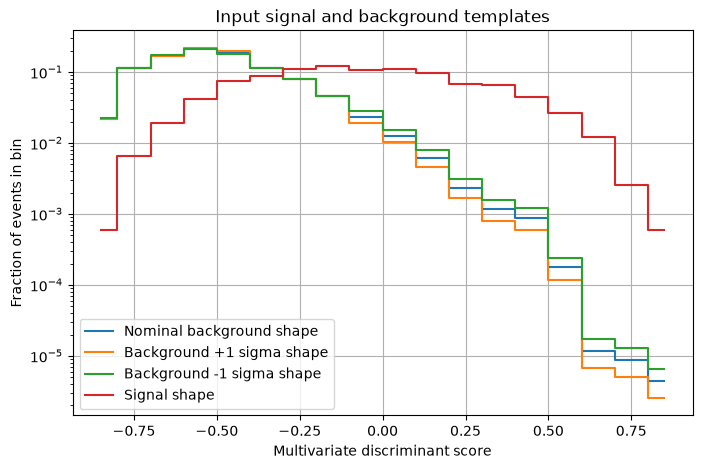

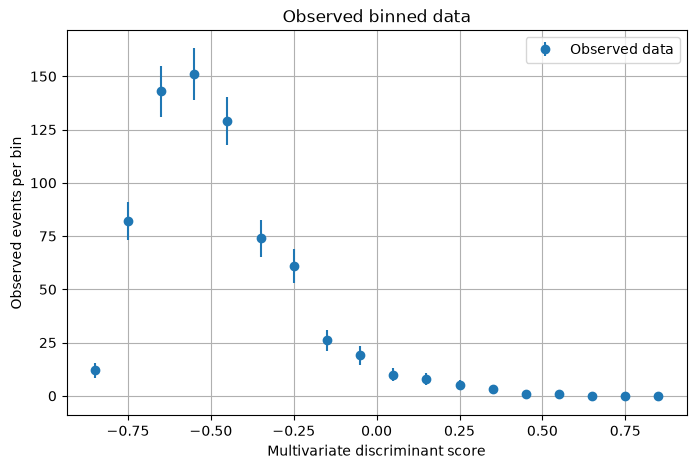

In [3]:
# Plot the input templates and the observed data

# First plot the normalized templates.
# These show shapes, not absolute event counts.
fig, ax = plt.subplots()
ax.step(bin_centers, b_pdf, where="mid", label="Nominal background shape")
ax.step(bin_centers, b1_pdf, where="mid", label="Background +1 sigma shape")
ax.step(bin_centers, b2_pdf, where="mid", label="Background -1 sigma shape")
ax.step(bin_centers, s_pdf, where="mid", label="Signal shape")
ax.set_yscale("log")
ax.set_xlabel("Multivariate discriminant score")
ax.set_ylabel("Fraction of events in bin")
ax.set_title("Input signal and background templates")
ax.legend()
plt.show()

# Now plot the data counts.
# The vertical error bars are sqrt(N), shown only to visualize the scale
# of counting fluctuations. They are not manually inserted into the NLL.
fig, ax = plt.subplots()
ax.errorbar(
    bin_centers,
    data,
    yerr=np.sqrt(np.maximum(data, 1.0)),  # avoid zero-length bars for empty bins
    fmt="o",
    label="Observed data"
)
ax.set_xlabel("Multivariate discriminant score")
ax.set_ylabel("Observed events per bin")
ax.set_title("Observed binned data")
ax.legend()
plt.show()

## 8. Code for the background-shape nuisance

The function below implements a simple piecewise vertical morphing rule:

$$
b_i(\alpha)=
\begin{cases}
 b_i^0+\alpha(b_i^+-b_i^0), & \alpha\ge 0,\\
 b_i^0+(-\alpha)(b_i^--b_i^0), & \alpha<0.
\end{cases}
$$

So $\alpha=0$ gives the nominal template, $\alpha=+1$ gives `b1_pdf`, and $\alpha=-1$ gives `b2_pdf`.

After morphing, I clip extremely small/negative values and renormalize. Renormalization is important because $B$ should remain the total background yield.

In [ ]:
import helper_ex1 as ex1_helper
from helper_ex1 import *

# Quick sanity checks.
print("Morphing sanity checks:")
print(f"  alpha =  0: sum = {morph_background(0).sum():.6f}")
print(f"  alpha = +1: sum = {morph_background(+1).sum():.6f}")
print(f"  alpha = -1: sum = {morph_background(-1).sum():.6f}")
print(f"  max |morph(+1)-b1_pdf| = {np.max(np.abs(morph_background(+1)-b1_pdf)):.3e}")
print(f"  max |morph(-1)-b2_pdf| = {np.max(np.abs(morph_background(-1)-b2_pdf)):.3e}")

Morphing sanity checks:
  alpha =  0: sum = 1.000000
  alpha = +1: sum = 1.000000
  alpha = -1: sum = 1.000000
  max |morph(+1)-b1_pdf| = 0.000e+00
  max |morph(-1)-b2_pdf| = 0.000e+00


## 9. Code for the expected counts $\mu_i$

The function below converts fit parameters into predicted event counts in every bin:

$$
\mu_i = S s_i + B b_i(\alpha).
$$

This is the central model of the whole exercise.

In [ ]:
from helper_ex1 import *

# Example: inspect what the model predicts for arbitrary trial parameters.
trial_S = 20.0
trial_B = 705.0
trial_alpha = 0.0
trial_mu = expected_counts(trial_S, trial_B, trial_alpha)

print(f"For trial S={trial_S}, B={trial_B}, alpha={trial_alpha}:")
print(f"  total predicted events = {trial_mu.sum():.3f}")
print(f"  first five predicted bin counts = {trial_mu[:5]}")

For trial S=20.0, B=705.0, alpha=0.0:
  total predicted events = 725.000
  first five predicted bin counts = [ 15.57394771  81.88341588 120.52727238 151.89539636 134.93165496]


## 10. Code for the extended binned NLL

For each bin, the Poisson likelihood is

$$
P(d_i\mid\mu_i)=\frac{\mu_i^{d_i}e^{-\mu_i}}{d_i!}.
$$

The product over bins is the likelihood. Taking the negative log and dropping the constant $\ln(d_i!)$ terms gives

$$
\text{NLL}=\sum_i \left(\mu_i-d_i\ln\mu_i\right).
$$

The constants can be dropped because they depend only on the observed data, not on the fit parameters. Dropping constants changes the absolute NLL value but not the location of the minimum or the $\Delta\text{NLL}$ curve.

In [ ]:
from helper_ex1 import *

# Evaluate the NLL at the arbitrary trial point from above.
print(f"NLL at S={trial_S}, B={trial_B}, alpha={trial_alpha}: {nll_ex1([trial_S, trial_B, trial_alpha]):.3f}")

NLL at S=20.0, B=705.0, alpha=0.0: -2515.322


## 11. Full fits: with and without the background-shape systematic

Now we minimize the NLL.

- Without the shape systematic: fit $(S,B)$ with $\alpha=0$ fixed.
- With the shape systematic: fit $(S,B,\alpha)$ and include the $\alpha^2/2$ constraint.

This is the numerical version of “find the parameters that make the observed data most likely.”

In [ ]:
from helper_ex1 import *

# NLL minimization

# Perform both fits.
fit_no_shape = fit_ex1(include_shape_systematic=False)
fit_with_shape = fit_ex1(include_shape_systematic=True)

ex1_helper.fit_no_shape = fit_no_shape
ex1_helper.fit_with_shape = fit_with_shape

# Print results in a readable way.
print("Fit WITHOUT background shape systematic")
print("--------------------------------------")
print(f"converged: {fit_no_shape.success}")
print(f"S_hat    = {fit_no_shape.x[0]:.3f} events")
print(f"B_hat    = {fit_no_shape.x[1]:.3f} events")
print(f"NLL_min  = {fit_no_shape.fun:.3f}")
print()

print("Fit WITH profiled background shape systematic")
print("---------------------------------------------")
print(f"converged:  {fit_with_shape.success}")
print(f"S_hat     = {fit_with_shape.x[0]:.3f} events")
print(f"B_hat     = {fit_with_shape.x[1]:.3f} events")
print(f"alpha_hat = {fit_with_shape.x[2]:.3f} sigma")
print(f"NLL_min   = {fit_with_shape.fun:.3f}")

Fit WITHOUT background shape systematic
--------------------------------------
converged: True
S_hat    = 23.506 events
B_hat    = 701.508 events
NLL_min  = -2515.384

Fit WITH profiled background shape systematic
---------------------------------------------
converged:  True
S_hat     = 20.013 events
B_hat     = 705.000 events
alpha_hat = -0.411 sigma
NLL_min   = -2515.537


## 12. Visualize the fitted model

The model prediction has two stacked pieces:

$$
\text{signal in bin } i = \hat S s_i,
$$

$$
\text{background in bin } i = \hat B b_i(\hat\alpha).
$$

The stacked histogram is the fitted $S+B$ prediction. The data points are overlaid with $\sqrt{N}$ error bars for visual guidance.

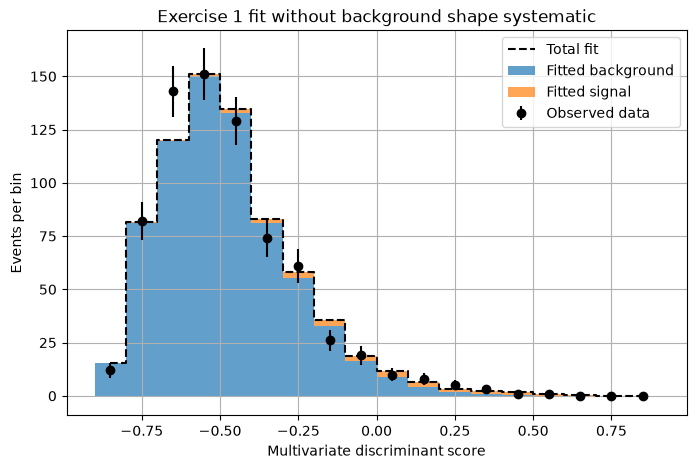

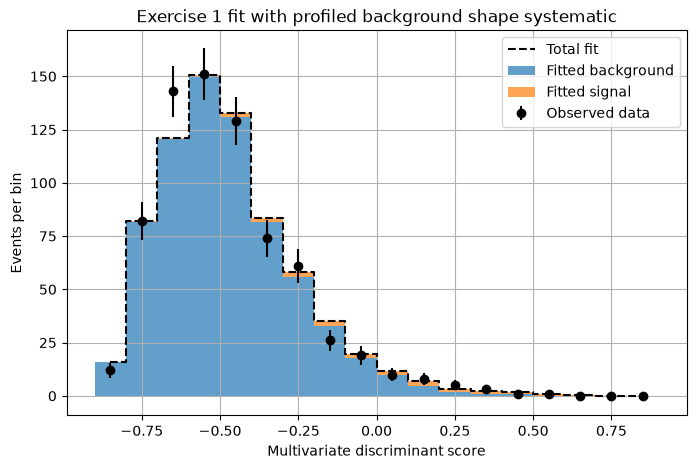

In [ ]:
from helper_ex1 import *

# Stacked fit plots

sig_no, bkg_no, total_no = plot_fit_result(
    fit_no_shape,
    include_shape_systematic=False,
    title="Exercise 1 fit without background shape systematic",
)

sig_shape, bkg_shape, total_shape = plot_fit_result(
    fit_with_shape,
    include_shape_systematic=True,
    title="Exercise 1 fit with profiled background shape systematic",
)

## 13. Profile likelihood scan in $S$

The full fit gives one best-fit value $\hat S$. To get the uncertainty on $S$, we scan possible fixed values of $S$.

For each fixed $S$, we refit the nuisance parameters:

- Without shape systematic: refit $B$.
- With shape systematic: refit $B$ and $\alpha$.

This gives the profile NLL:

$$
\text{NLL}_{\text{profile}}(S)=\min_{B,\alpha}\text{NLL}(S,B,\alpha).
$$

Then we plot

$$
\Delta\text{NLL}(S)=\text{NLL}_{\text{profile}}(S)-\text{NLL}_{\min}.
$$

The approximate one-standard-deviation interval for one parameter is where $\Delta\text{NLL}=0.5$.

In [ ]:
from helper_ex1 import *

# Profile likelihood scan in S

# Scan S values from 0 to 120 signal events.
S_scan = np.linspace(0.0, 120.0, 601)

# Profile scan without the shape systematic.
nll_scan_no_shape, nuisance_no_shape = profile_scan_in_S(False, S_scan)
delta_nll_no_shape = nll_scan_no_shape - fit_no_shape.fun

# Profile scan with the shape systematic.
nll_scan_with_shape, nuisance_with_shape = profile_scan_in_S(True, S_scan)
delta_nll_with_shape = nll_scan_with_shape - fit_with_shape.fun

# Find Delta NLL = 0.5 intervals.
lo_no, hi_no = find_interval_from_delta_nll(S_scan, delta_nll_no_shape, level=0.5)
lo_shape, hi_shape = find_interval_from_delta_nll(S_scan, delta_nll_with_shape, level=0.5)

print("Profile-likelihood intervals using Delta NLL = 0.5")
print("--------------------------------------------------")
print(
    f"Without shape systematic: S = {fit_no_shape.x[0]:.2f} "
    f"+{hi_no - fit_no_shape.x[0]:.2f} -{fit_no_shape.x[0] - lo_no:.2f} events"
)
print(
    f"With shape systematic:    S = {fit_with_shape.x[0]:.2f} "
    f"+{hi_shape - fit_with_shape.x[0]:.2f} -{fit_with_shape.x[0] - lo_shape:.2f} events"
)

Profile-likelihood intervals using Delta NLL = 0.5
--------------------------------------------------
Without shape systematic: S = 23.51 +10.94 -9.50 events
With shape systematic:    S = 20.01 +12.52 -11.11 events


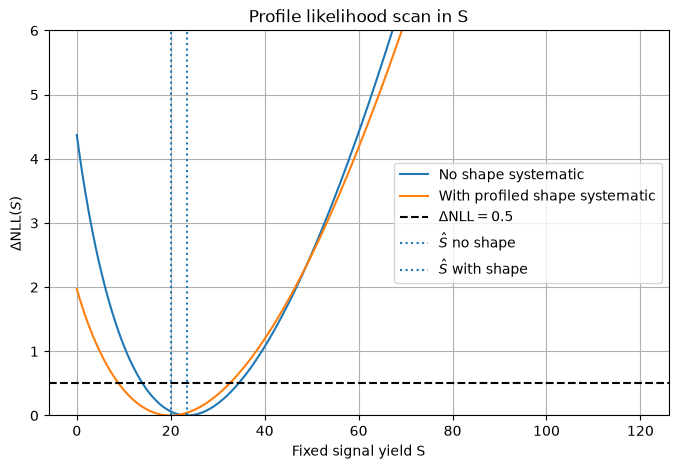

In [11]:
# Plot Delta NLL scans

fig, ax = plt.subplots()
ax.plot(S_scan, delta_nll_no_shape, label="No shape systematic")
ax.plot(S_scan, delta_nll_with_shape, label="With profiled shape systematic")
ax.axhline(0.5, linestyle="--", color="black", label=r"$\Delta\mathrm{NLL}=0.5$")
ax.axvline(fit_no_shape.x[0], linestyle=":", label=r"$\hat S$ no shape")
ax.axvline(fit_with_shape.x[0], linestyle=":", label=r"$\hat S$ with shape")
ax.set_xlabel("Fixed signal yield S")
ax.set_ylabel(r"$\Delta\mathrm{NLL}(S)$")
ax.set_title("Profile likelihood scan in S")
ax.set_ylim(0, 6)
ax.legend()
plt.show()

## 14. Seeing the local parabola explicitly

The scan above is the actual profile likelihood curve. Near the minimum it should be approximately quadratic:

$$
\Delta\text{NLL}(S) \approx \frac{(S-\hat S)^2}{2\sigma_S^2}.
$$

So the curvature determines the uncertainty:

$$
\Delta\text{NLL}=0.5 \quad \Rightarrow \quad |S-\hat S|=\sigma_S.
$$

The code below fits a parabola only to points near the minimum and overlays that local approximation. This is the connection to the “minimum of a parabola” idea.

Local parabolic approximations
------------------------------
No shape systematic:  S_min ~ 24.76, sigma ~ 10.35
With shape systematic: S_min ~ 21.33, sigma ~ 11.90


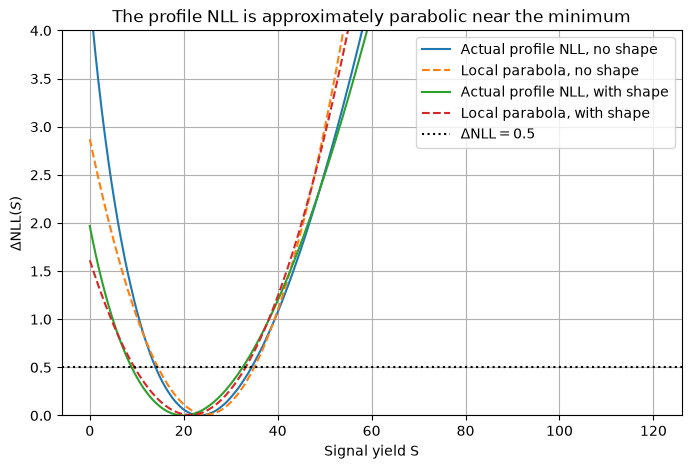

In [ ]:
from helper_ex1 import *

# Parabolic approximation near the NLL minimum

S_par_no, sigma_par_no, parabola_no = fit_local_parabola(S_scan, delta_nll_no_shape)
S_par_shape, sigma_par_shape, parabola_shape = fit_local_parabola(S_scan, delta_nll_with_shape)

print("Local parabolic approximations")
print("------------------------------")
print(f"No shape systematic:  S_min ~ {S_par_no:.2f}, sigma ~ {sigma_par_no:.2f}")
print(f"With shape systematic: S_min ~ {S_par_shape:.2f}, sigma ~ {sigma_par_shape:.2f}")

fig, ax = plt.subplots()
ax.plot(S_scan, delta_nll_no_shape, label="Actual profile NLL, no shape")
ax.plot(S_scan, parabola_no, linestyle="--", label="Local parabola, no shape")
ax.plot(S_scan, delta_nll_with_shape, label="Actual profile NLL, with shape")
ax.plot(S_scan, parabola_shape, linestyle="--", label="Local parabola, with shape")
ax.axhline(0.5, linestyle=":", color="black", label=r"$\Delta\mathrm{NLL}=0.5$")
ax.set_xlabel("Signal yield S")
ax.set_ylabel(r"$\Delta\mathrm{NLL}(S)$")
ax.set_title("The profile NLL is approximately parabolic near the minimum")
ax.set_ylim(0, 4)
ax.legend()
plt.show()

## 15. Optional comparison to a $\chi^2$ fit

A rough large-count $\chi^2$ objective is

$$
\chi^2(S,B,\alpha)=\sum_i \frac{(d_i-\mu_i)^2}{\mu_i}.
$$

This is not the requested fit, but it is useful for intuition. It shows how bins are weighted: bins with larger expected fluctuations get smaller weight.

The likelihood fit is preferred here because it is the exact count model for binned Poisson data, while the $\chi^2$ version is an approximation.

In [ ]:
from helper_ex1 import *

# Optional: compare the NLL fit to a Pearson chi-square value

chi2_no = pearson_chi2(total_no)
chi2_shape = pearson_chi2(total_shape)
ndof_no = len(data) - 2       # bins minus fitted parameters S,B
ndof_shape = len(data) - 3    # bins minus fitted parameters S,B,alpha

print("Pearson chi-square values evaluated at the NLL best fits")
print("-------------------------------------------------------")
print(f"No shape systematic:  chi2 = {chi2_no:.2f}, ndof ~ {ndof_no}, chi2/ndof ~ {chi2_no/ndof_no:.2f}")
print(f"With shape systematic: chi2 = {chi2_shape:.2f}, ndof ~ {ndof_shape}, chi2/ndof ~ {chi2_shape/ndof_shape:.2f}")

Pearson chi-square values evaluated at the NLL best fits
-------------------------------------------------------
No shape systematic:  chi2 = 11.47, ndof ~ 16, chi2/ndof ~ 0.72
With shape systematic: chi2 = 11.04, ndof ~ 15, chi2/ndof ~ 0.74


## 16. Summary of the conceptual picture

1. The data are binned event counts $d_i$.
2. The signal and background PDFs are normalized shapes, not absolute counts.
3. The fit parameters $S$ and $B$ turn those shapes into absolute expected counts:

   $$
   \mu_i = S s_i + B b_i.
   $$

4. The likelihood asks: if the true expected bin counts were $\mu_i$, how likely would it be to observe the actual counts $d_i$?
5. Because the data are counts, the natural bin probability is Poisson.
6. The Poisson likelihood automatically accounts for statistical uncertainty; we do not manually weight each bin by an externally chosen uncertainty.
7. A background-shape systematic is represented by a nuisance parameter $\alpha$ that morphs the background template and is constrained by $\alpha^2/2$.
8. A profile likelihood scan fixes $S$ and refits nuisance parameters. This gives $\Delta\text{NLL}(S)$.
9. Near the best fit, the NLL is approximately a parabola. The usual one-parameter $1\sigma$ uncertainty comes from $\Delta\text{NLL}=0.5$.

For this toy data set, the fit gives a small positive signal estimate. Including the profiled background-shape systematic shifts the best-fit signal slightly lower and increases the uncertainty, as expected when the background model is allowed to move.